In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_swiss_roll
import pickle, gzip
import os, time

In [21]:
import matplotlib.pyplot as plt

In [35]:
from sklearn.preprocessing import StandardScaler

load the mnist data:

In [3]:
f = gzip.open('../../data/mnist.pkl.gz','rb')
train_set, val_set, test_set = pickle.load(f, encoding='latin1')
f.close()

In [4]:
X_train, y_train = train_set[0], train_set[1]
X_validation, y_validation = val_set[0], val_set[1]
X_test, y_test = test_set[0], test_set[1]

In [5]:
X_train.shape

(50000, 784)

Load up the non-linear dataset....

In [6]:
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

PCA is great for linear data.
- can perform some checks on the data to test whether its linear or not.. not suited for PCA..

In [7]:
linear_dataset1 = pd.read_csv('../../data/Seed_Data.csv')[['A','LK']]
linear_dataset2 = X_train
nonlinear_dataset = X_swiss

Linearity checks....

Fasstest first check:
- PCA explained variance:
  - first 2-5 components capture > 80% of the variance
  - if there's need for 50% components for 80% -> non linear structure is likely present, linear methods losing information
  - explained variance: cumulative curve that rises steeply then flattens -> linear
  - explained variance rises slowly and steadily -> non linear 

In [8]:
from sklearn.decomposition import PCA

In [36]:
pca_ld1 = PCA()
sc1 = StandardScaler()
pca_ld2 = PCA()
sc2 = StandardScaler()
pca_nld = PCA()
sc3 = StandardScaler()

In [37]:
pca_ld1.fit(sc1.fit_transform(linear_dataset1.values))
pca_ld2.fit(sc2.fit_transform(linear_dataset2))
pca_nld.fit(sc3.fit_transform(nonlinear_dataset))

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

linear dataset1 - first principal component captures 99% of the variance - very linear....

In [38]:
pca_ld1.explained_variance_ratio_

array([0.97499271, 0.02500729])

linear dataset 2

In [39]:
len(pca_ld2.explained_variance_ratio_)

784

In [40]:
np.argwhere(np.cumsum(pca_ld2.explained_variance_ratio_) > 0.8)[0]

array([147])

takes about 43 ... out of the 784 components to capture 80% of the variance hence its linear....

non linear dataset..

In [41]:
pca_nld.explained_variance_ratio_

array([0.38603589, 0.32653462, 0.28742949])

its a 3-dimensional dataset.. its first component should be taking up most of that variance but doesn't...non linea

Text(0.5, 0, 'Components')

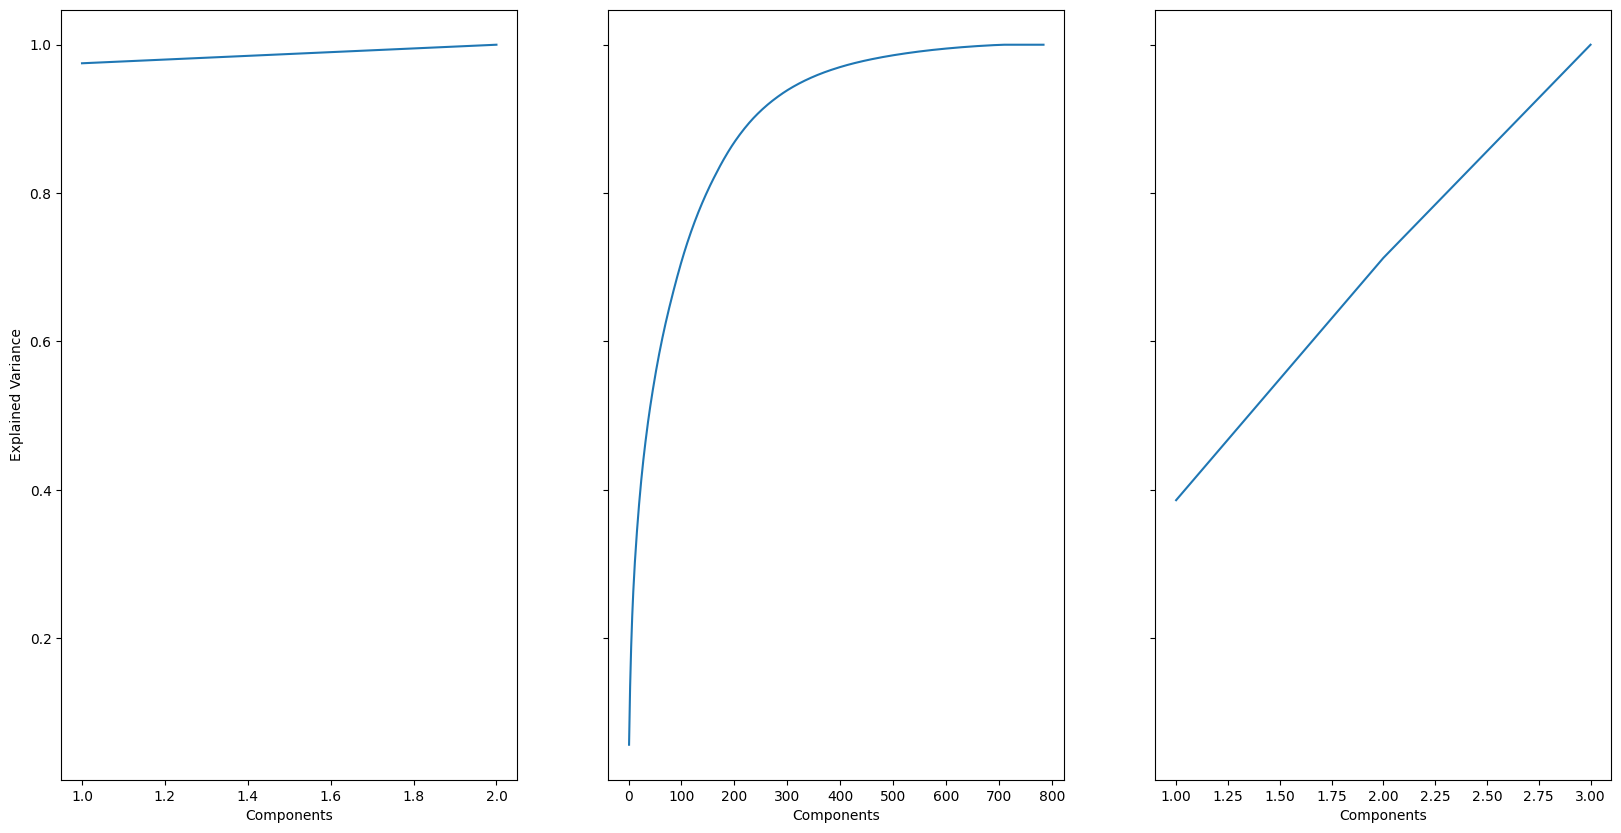

In [42]:
fig, ax = plt.subplots(1,3, figsize=(20,10), sharey=True)
ax[0].plot(np.arange(len(pca_ld1.explained_variance_ratio_))+1, np.cumsum(pca_ld1.explained_variance_ratio_))
ax[0].set_xlabel('Components')
ax[0].set_ylabel('Explained Variance')
ax[1].plot(np.arange(len(pca_ld2.explained_variance_ratio_))+1, np.cumsum(pca_ld2.explained_variance_ratio_))
ax[1].set_xlabel('Components')
ax[2].plot(np.arange(len(pca_nld.explained_variance_ratio_))+1, np.cumsum(pca_nld.explained_variance_ratio_))
ax[2].set_xlabel('Components')

curve 3 - rises slowly..... non linearr.
explained variance curves for linear datasets ought to rise steeply and flatten.. or be already high

Check 2: Residual Reconstruction error:
- if pca can reconstruct your data well with few components...then its probably linear...

In [44]:
sc = StandardScaler()

for k in [1,2]:
    x_scaled = sc.fit_transform(linear_dataset1)
    pca = PCA(n_components = k)
    X_reconstructed = pca.inverse_transform(pca.fit_transform(x_scaled))
    error = np.mean((x_scaled - X_reconstructed)**2)
    print(f"k={k}: reconstruction error={error:.4f}")

k=1: reconstruction error=0.0250
k=2: reconstruction error=0.0000


above dataset: 2 dimensions...reconstruction error with 1 component..relatively small so its linear..

In [46]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [47]:
sc = StandardScaler()

for k in [10, 50, 100, 150, 200, 400, 600, 700]:
    x_scaled = sc.fit_transform(linear_dataset2)
    pca = PCA(n_components = k)
    X_reconstructed = pca.inverse_transform(pca.fit_transform(x_scaled))
    error = np.mean((x_scaled - X_reconstructed)**2)
    print(f"k={k}: reconstruction error={error:.4f}")

k=10: reconstruction error=0.6613
k=50: reconstruction error=0.4094
k=100: reconstruction error=0.2674
k=150: reconstruction error=0.1792
k=200: reconstruction error=0.1201
k=400: reconstruction error=0.0275
k=600: reconstruction error=0.0047
k=700: reconstruction error=0.0002


- from above...can see that error drops sharply from k=10 to k=200.....then plateaus... so its a linear dataset...
- if the error decreases slowly and never really plateaus, then the data is non linear...

Other checks worth considering:
- Compare PCA and KernelPCA on a downstream task e.g. clustering and comparing silhoutee scores
- Visual sanity check - reduce to 2D with both PCA and something like UMAP then plot..PCA shows clear struct and clusters - linear | PCA shows a blob and umap shows clusters -> non linearity missed by pca..

PCA fails on manifolds and non-linear data:
- because of one fundamental assumption baked into its math assumptios:
  - "The directions of maximum variance are straight lines through the data"
- Everything PCA does flows from this assumption and when its wrong PCA fails
- In non linear data - variance in the dataset doesn't flow in straightlines - could be folded like in manifolds....

- **Geometrically:**
  - PCA finds a set of orthogonal axes - straightlines - that capture maximum variance. It then projects your data onto these lines
    - Thats why if in your dataset you find that there's multiple components, each with a significant chunk of explainable variance and not one particular set of components doing all the heavy lifting then that probably means your dataset is non-linear and PCA tried to find a huge chunk of orthogonal axes to project this data to...